In [24]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [25]:
# Define paths
base_path = Path('data/raw/chest_xray')

train_path = base_path / 'train'
test_path = base_path / 'test'
val_path = base_path / 'val'

print(f"Train path: {train_path}")
print(f"Test path:  {test_path}")
print(f"Val path:   {val_path}")

Train path: data\raw\chest_xray\train
Test path:  data\raw\chest_xray\test
Val path:   data\raw\chest_xray\val


In [26]:
# Image size ResNet expects
IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(f"\nTraining transforms:   {len(train_transforms.transforms)} steps")
print(f"Test transforms:       {len(test_transforms.transforms)} steps")


Training transforms:   6 steps
Test transforms:       3 steps


In [27]:
# NORMAL/ - label 0
# PNEUMONIA/ - label 1

train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transforms
)

val_dataset = datasets.ImageFolder(
    root=val_path,
    transform=test_transforms
)
print(f"Classes: {train_dataset.classes}")
print(f"Class index mapping: {train_dataset.class_to_idx}")
print(f"\nTraining samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")

Classes: ['NORMAL', 'PNEUMONIA']
Class index mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Training samples:   5,216
Validation samples: 16
Test samples:       624


In [28]:
class_counts = np.bincount(train_dataset.targets)
print(f"Class distribution:")
print(f"   NORMAL:    {class_counts[0]:,}")
print(f"   PNEUMONIA: {class_counts[1]:,}")
print(f"   Ratio:     {class_counts[1]/class_counts[0]:.1f}x more pneumonia")

class_weights = 1.0 / class_counts
sample_weights = class_weights[train_dataset.targets]
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"Class weights:")
print(f"   NORMAL weight:    {class_weights[0]:.4f}")
print(f"   PNEUMONIA weight: {class_weights[1]:.4f}")
print(f"   Ratio:  {class_weights[0]/class_weights[1]:.1f}x more normal samples")


Class distribution:
   NORMAL:    1,341
   PNEUMONIA: 3,875
   Ratio:     2.9x more pneumonia
Class weights:
   NORMAL weight:    0.0007
   PNEUMONIA weight: 0.0003
   Ratio:  2.9x more normal samples


In [29]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, 
    BATCH_SIZE, 
    sampler=sampler
)

test_loader = DataLoader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
)

val_loader = DataLoader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
)

In [30]:
iterator = iter(train_loader)
images, labels = next(iterator)
print("Single batch inspection")
print(f"Image tensor shape: {images.shape}")
print(f"Batch size: {images.shape[0]}")
print(f"RGB channels: {images.shape[1]}")
print(f"Dimensions: {images.shape[2]}x{images.shape[3]}")
print(f"Normalized pixel range: {images.min()} - {images.max()}")

Single batch inspection
Image tensor shape: torch.Size([32, 3, 224, 224])
Batch size: 32
RGB channels: 3
Dimensions: 224x224
Normalized pixel range: -2.1179039478302 - 2.640000104904175


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.3785625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831376].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..1.6813945].


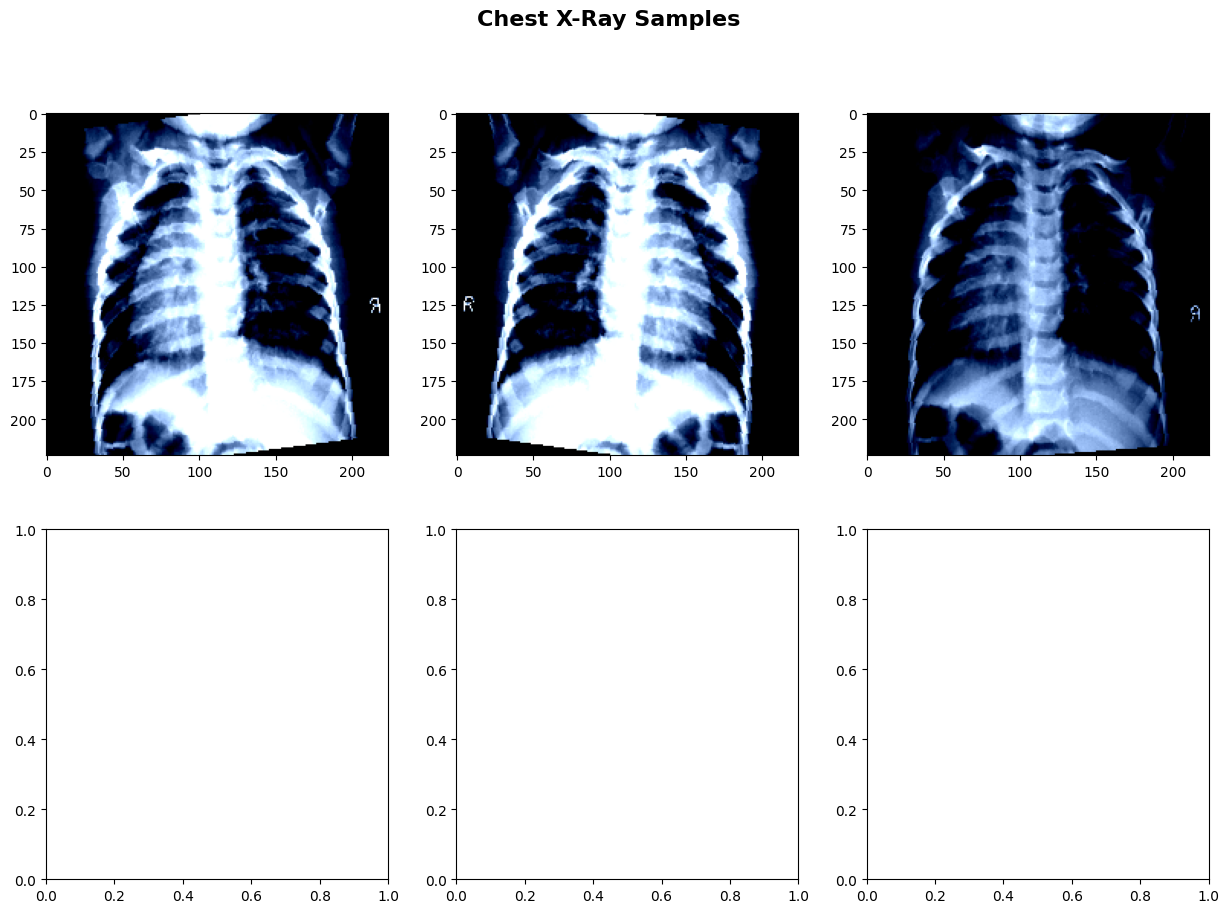

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
normal_image = Image.open(random.choice(list((train_path / 'NORMAL').glob('*.jpeg')))).convert('RGB')
pneumonia_image = Image.open(random.choice(list((train_path / 'PNEUMONIA').glob('*.jpeg')))).convert('RGB')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Chest X-Ray Samples', fontsize=16, fontweight='bold')

for i in range (3):
    transformed_Nimage = train_transforms(normal_image)
    transformed_Pimage = train_transforms(pneumonia_image)
    axes[0, i].imshow(
        transformed_Nimage.permute(1, 2, 0).numpy()
    )
    axes[0, i].set_title(f'NORMAL\n{img_path.stem[:30]}', fontsize=10)
    axes[0, i].axis('off')

    axes[0, i].imshow(
        transformed_Nimage.permute(1, 2, 0).numpy()
    )
    axes[0, i].set_title(f'NORMAL\n{img_path.stem[:30]}', fontsize=10)
    axes[0, i].axis('off')

